# DFloat11-TT Presentation Visuals

Run this notebook after one of the pipeline scripts finishes. It reads `results/aggregate.json`, eval configs, and compressed bundle headers from the repo.

In [11]:
!pip install pandas seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [12]:
from pathlib import Path
from collections import Counter, defaultdict
import json
import os
import struct

REPO = Path.cwd().resolve()
if REPO.name == "viz":
    REPO = REPO.parent
os.environ.setdefault("MPLCONFIGDIR", str(REPO / ".matplotlib_cache"))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yaml
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="talk", palette="Set2")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.titlesize": 15,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

print(f"Repo: {REPO}")

Repo: /home/tomasissac/dfloat11_tt


In [13]:
def read_json(path, default):
    path = Path(path)
    if not path.exists():
        return default
    with path.open() as f:
        return json.load(f)


def read_yaml(path):
    with Path(path).open() as f:
        return yaml.safe_load(f)


def short_model_name(model_id):
    return model_id.split("/")[-1].replace("-Instruct", "")


def classify_tensor(name):
    if "embed_tokens" in name:
        return "embedding"
    if name == "lm_head" or name.endswith(".lm_head"):
        return "lm_head"
    for key in ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]:
        if name.endswith(key):
            return key
    return "other"


def mb(x):
    return x / 1e6


def scan_df11tt_bundle(path):
    """Read only bundle headers and byte counts. This avoids loading tensor payloads."""
    path = Path(path)
    tensors = []
    if not path.exists():
        return tensors

    with path.open("rb") as f:
        header = f.read(4)
        if len(header) != 4:
            return tensors
        (n_tensors,) = struct.unpack("<I", header)

        for _ in range(n_tensors):
            (name_len,) = struct.unpack("<I", f.read(4))
            name = f.read(name_len).decode("utf-8")
            magic = f.read(8)
            if magic != b"DF11TT01":
                raise ValueError(f"Bad bundle magic in {path}: {magic!r}")

            dtype, ndim = struct.unpack("<BB", f.read(2))
            shape = list(struct.unpack(f"<{ndim}Q", f.read(8 * ndim)))
            k, n_codes = struct.unpack("<BB", f.read(2))
            T, B, R_pad, C_pad = struct.unpack("<IIII", f.read(16))
            n_elements, n_bytes = struct.unpack("<QQ", f.read(16))

            lut_bytes = (k + 1) * 256
            exponent_bytes = n_bytes
            sign_mantissa_bytes = n_elements
            gap_bytes = (T * B * 5 + 7) // 8
            output_position_bytes = (B + 1) * 4
            compressed_bytes = lut_bytes + exponent_bytes + sign_mantissa_bytes + gap_bytes + output_position_bytes
            original_bytes = n_elements * 2

            f.seek(compressed_bytes, 1)

            tensors.append({
                "name": name,
                "kind": classify_tensor(name),
                "shape": "x".join(str(s) for s in shape),
                "rows": shape[0] if len(shape) > 0 else None,
                "cols": shape[1] if len(shape) > 1 else None,
                "k": k,
                "original_bytes": original_bytes,
                "compressed_bytes": compressed_bytes,
                "ratio": compressed_bytes / original_bytes if original_bytes else None,
            })
    return tensors


def config_paths_from_results(aggregate):
    paths = []
    for row in aggregate:
        cfg = row.get("config")
        if cfg:
            paths.append(REPO / cfg)
    if not paths:
        paths = sorted((REPO / "eval" / "configs").glob("*full.yaml"))

    seen = set()
    out = []
    for path in paths:
        path = path.resolve()
        if path not in seen and path.exists():
            seen.add(path)
            out.append(path)
    return out


def annotate_bars(ax, fmt="{:.1f}", dy=2):
    for container in ax.containers:
        labels = []
        for bar in container:
            value = bar.get_height()
            labels.append("" if pd.isna(value) else fmt.format(value))
        ax.bar_label(container, labels=labels, fontsize=9, padding=dy)


def finish(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    sns.despine(ax=ax)
    plt.tight_layout()

In [14]:
aggregate = read_json(REPO / "results" / "aggregate.json", [])
if isinstance(aggregate, dict):
    aggregate = [aggregate]

bundle_rows = []
tensor_rows = []

for cfg_path in config_paths_from_results(aggregate):
    cfg = read_yaml(cfg_path)
    bundle_path = REPO / cfg["bundle_path"]
    tensors = scan_df11tt_bundle(bundle_path)
    if not tensors:
        continue

    original = sum(t["original_bytes"] for t in tensors)
    compressed = sum(t["compressed_bytes"] for t in tensors)
    row = {
        "model_id": cfg["model_id"],
        "model": short_model_name(cfg["model_id"]),
        "config": str(cfg_path.relative_to(REPO)),
        "bundle_path": str(bundle_path.relative_to(REPO)),
        "n_tensors": len(tensors),
        "original_bytes": original,
        "compressed_bytes": compressed,
        "original_mb": mb(original),
        "compressed_mb": mb(compressed),
        "compression_pct": 100 * compressed / original if original else None,
        "saved_pct": 100 * (1 - compressed / original) if original else None,
    }
    bundle_rows.append(row)
    for t in tensors:
        tensor_rows.append({
            **t,
            "model_id": cfg["model_id"],
            "model": row["model"],
            "config": row["config"],
            "original_mb": mb(t["original_bytes"]),
            "compressed_mb": mb(t["compressed_bytes"]),
            "compression_pct": 100 * t["compressed_bytes"] / t["original_bytes"],
            "saved_pct": 100 * (1 - t["compressed_bytes"] / t["original_bytes"]),
        })

bundle_df = pd.DataFrame(bundle_rows)
tensor_df = pd.DataFrame(tensor_rows)

print(f"Loaded {len(aggregate)} result row(s), {len(bundle_df)} bundle row(s), {len(tensor_df)} tensor row(s).")
if not bundle_df.empty:
    display(bundle_df[["model", "n_tensors", "original_mb", "compressed_mb", "compression_pct", "saved_pct"]].round(2))

Loaded 1 result row(s), 1 bundle row(s), 114 tensor row(s).


,model,n_tensors,original_mb,compressed_mb,compression_pct,saved_pct
0,Llama-3.2-1B,114,2996.83,2031.45,67.79,32.21


## Output Equivalence

In [15]:
completion_rows = []
for row in aggregate:
    model = short_model_name(row.get("model_id", "unknown"))
    eq = row.get("output_equivalence", {})
    for item in eq.get("results", []):
        completion_rows.append({
            "model": model,
            "prompt": item.get("prompt"),
            "passed": item.get("passed"),
            "tokens_match": item.get("tokens_match"),
            "BF16 completion": item.get("ref_completion", "<not stored>"),
            "DF11 completion": item.get("df11_completion", "<not stored>"),
            "BF16 seconds": item.get("ref_generate_seconds"),
            "DF11 seconds": item.get("df11_generate_seconds"),
            "BF16 tok/s": item.get("ref_tokens_per_sec"),
            "DF11 tok/s": item.get("df11_tokens_per_sec"),
        })

completion_df = pd.DataFrame(completion_rows)
if completion_df.empty:
    print("No output equivalence results found yet.")
else:
    display(completion_df.head(8))

,model,prompt,passed,tokens_match,BF16 completion,DF11 completion,BF16 seconds,DF11 seconds,BF16 tok/s,DF11 tok/s
0,Llama-3.2-1B,The capital of France is,True,True,Paris. The Eiffel Tower is located in Paris. ...,Paris. The Eiffel Tower is located in Paris. ...,0.882846,259.359682,18.123198,0.06169


## Compression By Model

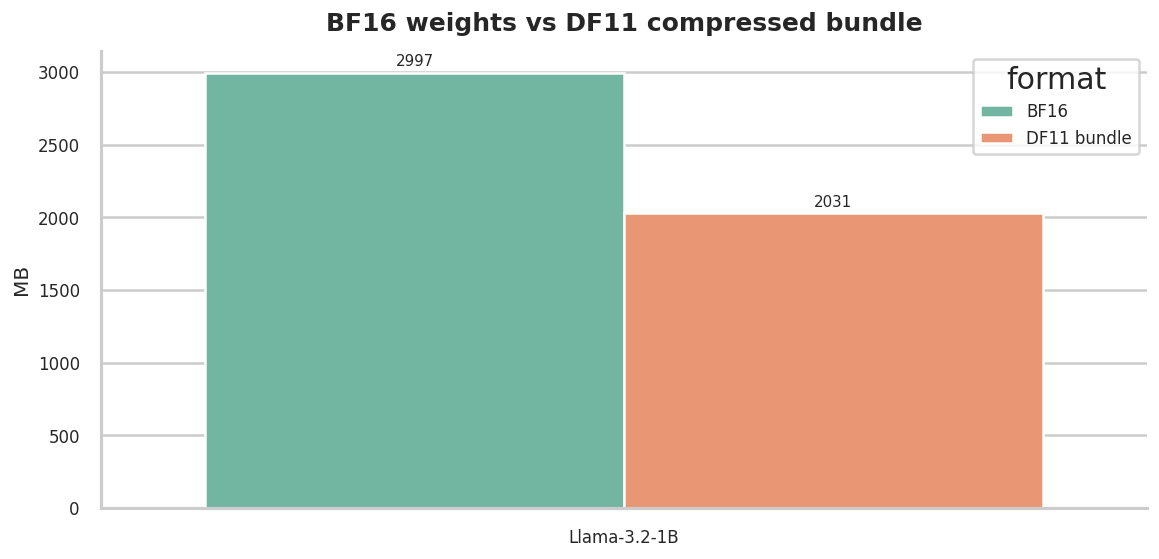

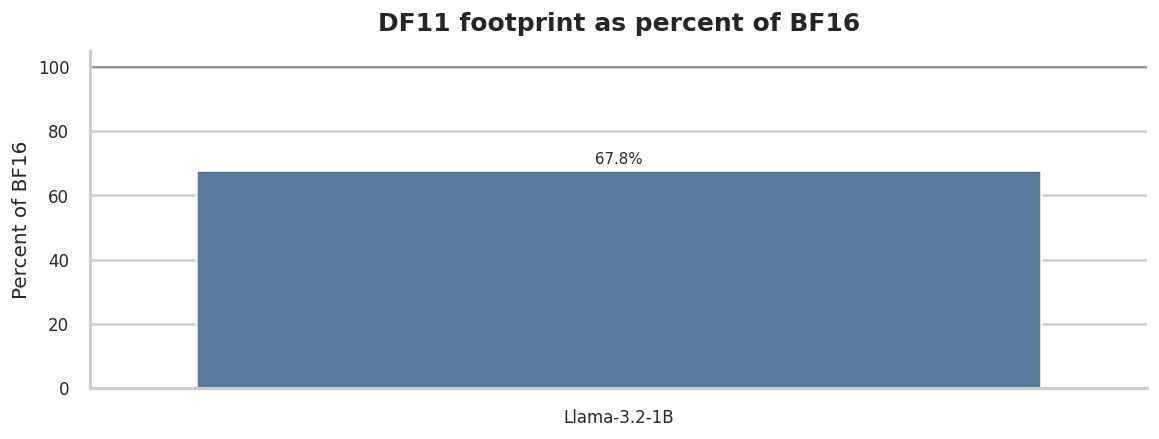

In [16]:
if bundle_df.empty:
    print("No compressed bundles found yet.")
else:
    size_df = bundle_df.melt(
        id_vars=["model"],
        value_vars=["original_mb", "compressed_mb"],
        var_name="format",
        value_name="MB",
    )
    size_df["format"] = size_df["format"].map({"original_mb": "BF16", "compressed_mb": "DF11 bundle"})

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=size_df, x="model", y="MB", hue="format", ax=ax)
    annotate_bars(ax, "{:.0f}")
    finish(ax, "BF16 weights vs DF11 compressed bundle", ylabel="MB")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=bundle_df, x="model", y="compression_pct", ax=ax, color="#4c78a8")
    ax.axhline(100, color="black", linewidth=1, alpha=0.35)
    annotate_bars(ax, "{:.1f}%")
    finish(ax, "DF11 footprint as percent of BF16", ylabel="Percent of BF16")
    plt.show()

## Compression By Tensor Type

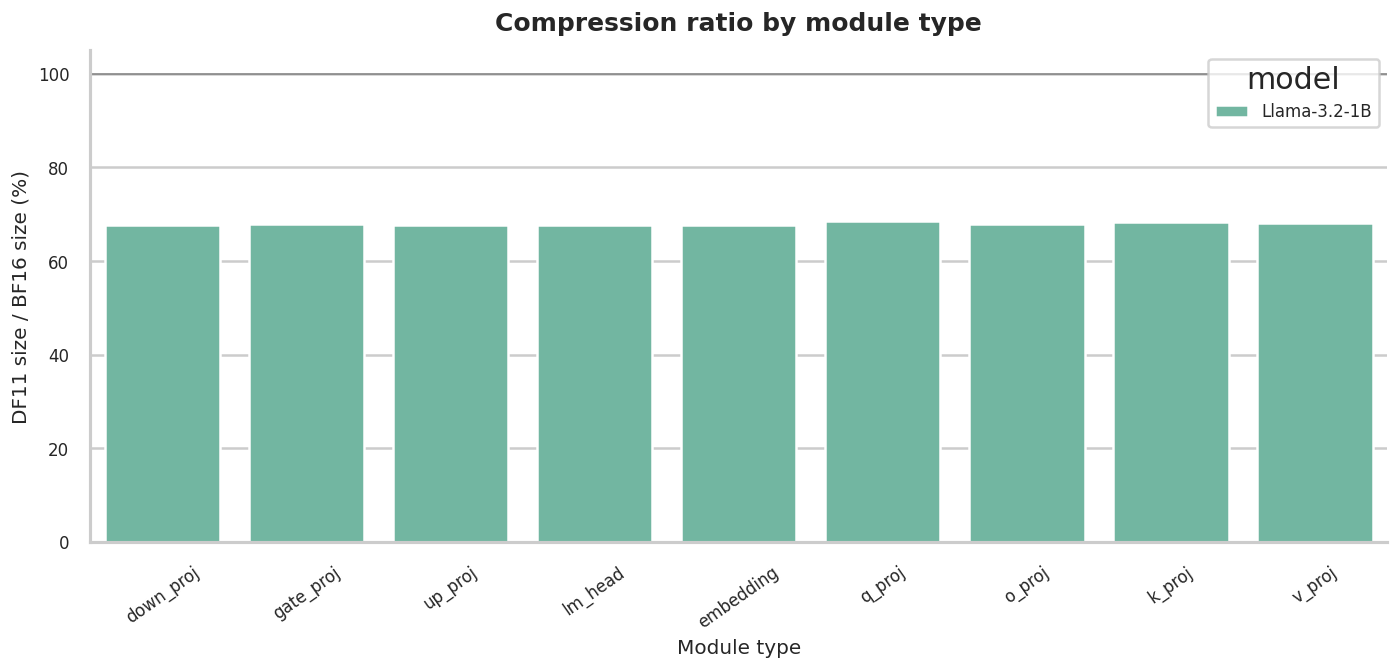

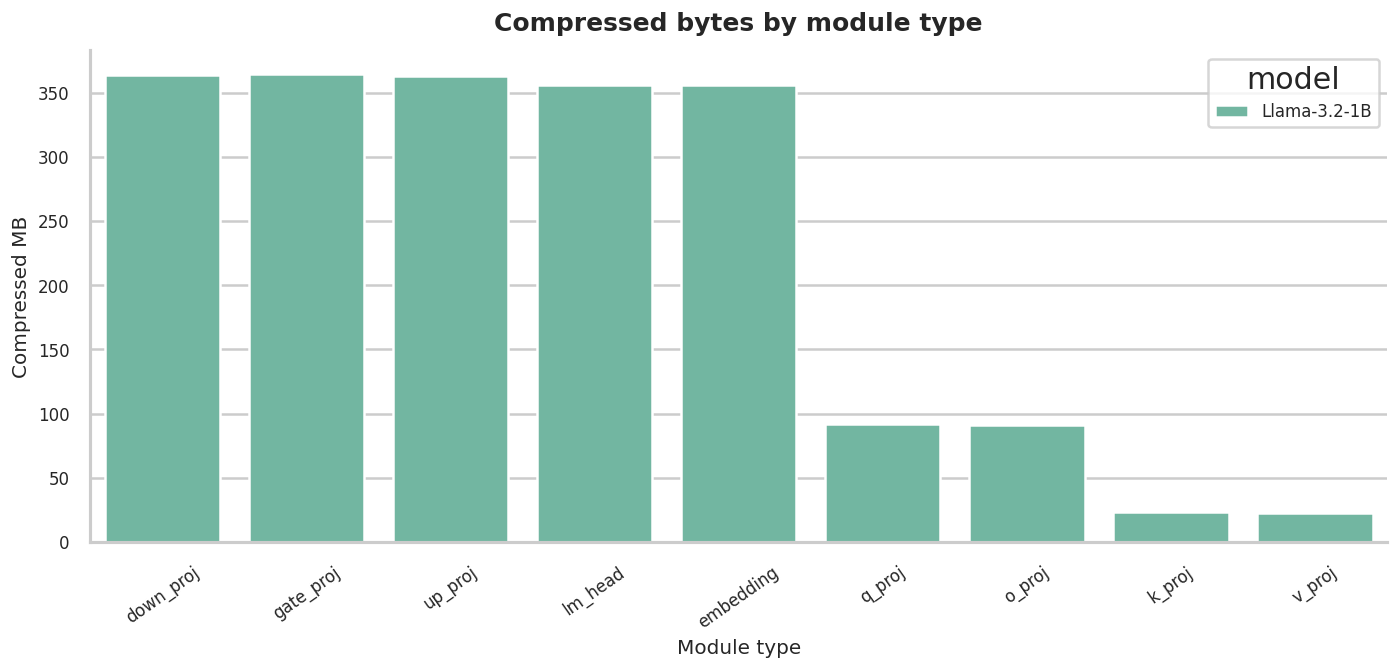

,model,kind,original_mb,compressed_mb,tensors,compression_pct
0,Llama-3.2-1B,down_proj,536.87,363.40,16,67.69
2,Llama-3.2-1B,gate_proj,536.87,364.58,16,67.91
7,Llama-3.2-1B,up_proj,536.87,363.09,16,67.63
1,Llama-3.2-1B,embedding,525.34,355.67,1,67.70
4,Llama-3.2-1B,lm_head,525.34,355.67,1,67.70
5,Llama-3.2-1B,o_proj,134.22,91.17,16,67.93
6,Llama-3.2-1B,q_proj,134.22,92.09,16,68.62
3,Llama-3.2-1B,k_proj,33.55,22.92,16,68.31
8,Llama-3.2-1B,v_proj,33.55,22.86,16,68.12


In [17]:
if tensor_df.empty:
    print("No tensor rows found yet.")
else:
    type_df = (
        tensor_df.groupby(["model", "kind"], as_index=False)
        .agg(original_mb=("original_mb", "sum"), compressed_mb=("compressed_mb", "sum"), tensors=("name", "count"))
    )
    type_df["compression_pct"] = 100 * type_df["compressed_mb"] / type_df["original_mb"]
    order = type_df.groupby("kind")["original_mb"].sum().sort_values(ascending=False).index

    fig, ax = plt.subplots(figsize=(12, 5.5))
    sns.barplot(data=type_df, x="kind", y="compression_pct", hue="model", order=order, ax=ax)
    ax.axhline(100, color="black", linewidth=1, alpha=0.35)
    finish(ax, "Compression ratio by module type", xlabel="Module type", ylabel="DF11 size / BF16 size (%)")
    ax.tick_params(axis="x", rotation=35)
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5.5))
    sns.barplot(data=type_df, x="kind", y="compressed_mb", hue="model", order=order, ax=ax)
    finish(ax, "Compressed bytes by module type", xlabel="Module type", ylabel="Compressed MB")
    ax.tick_params(axis="x", rotation=35)
    plt.show()

    display(type_df.sort_values(["model", "original_mb"], ascending=[True, False]).round(2))

## Generation Time And Throughput

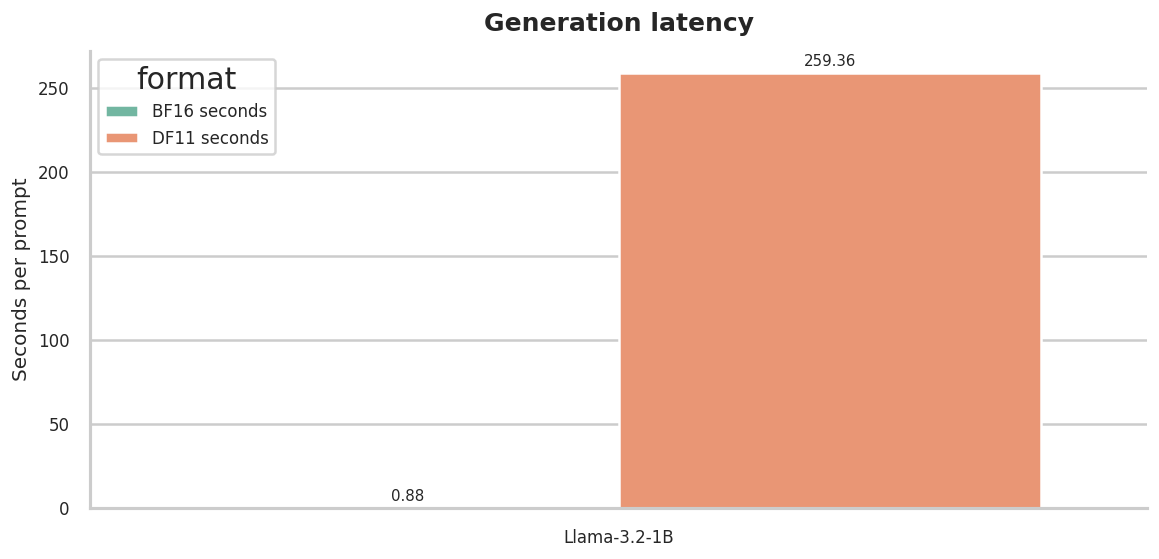

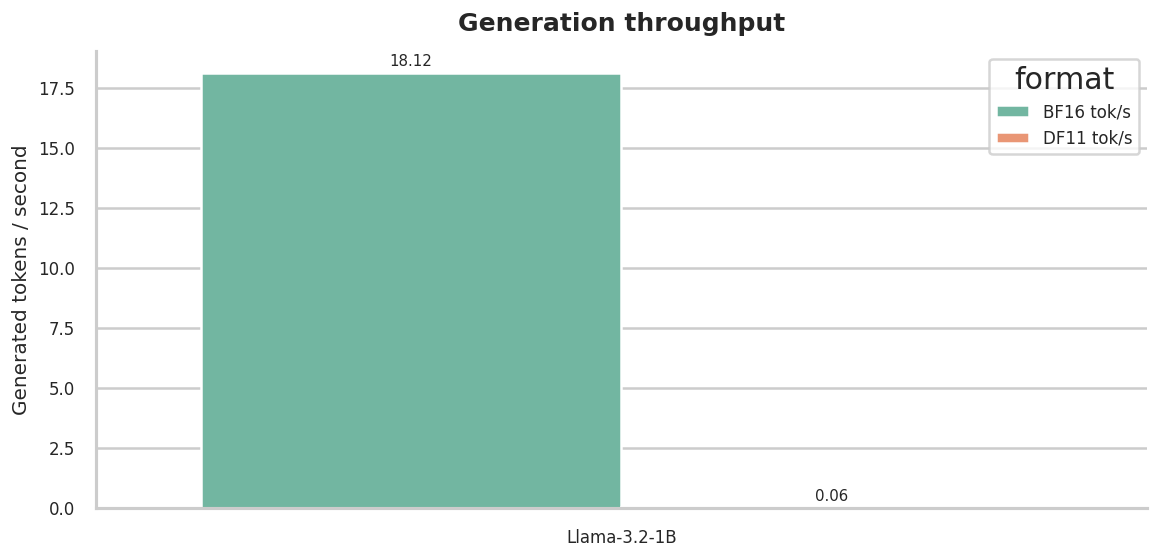

,model,BF16 seconds,DF11 seconds,BF16 tok/s,DF11 tok/s
0,Llama-3.2-1B,0.883,259.36,18.123,0.062


In [18]:
timing_rows = []
for row in aggregate:
    model = short_model_name(row.get("model_id", "unknown"))
    items = row.get("output_equivalence", {}).get("results", [])
    ref_times = [x.get("ref_generate_seconds") for x in items if x.get("ref_generate_seconds") is not None]
    df11_times = [x.get("df11_generate_seconds") for x in items if x.get("df11_generate_seconds") is not None]
    ref_tps = [x.get("ref_tokens_per_sec") for x in items if x.get("ref_tokens_per_sec") is not None]
    df11_tps = [x.get("df11_tokens_per_sec") for x in items if x.get("df11_tokens_per_sec") is not None]
    if ref_times and df11_times:
        timing_rows.append({
            "model": model,
            "BF16 seconds": sum(ref_times) / len(ref_times),
            "DF11 seconds": sum(df11_times) / len(df11_times),
            "BF16 tok/s": sum(ref_tps) / len(ref_tps) if ref_tps else None,
            "DF11 tok/s": sum(df11_tps) / len(df11_tps) if df11_tps else None,
        })

timing_df = pd.DataFrame(timing_rows)
if timing_df.empty:
    print("No timing fields found yet. Re-run a pipeline with the latest eval code to populate timing charts.")
else:
    latency_df = timing_df.melt(id_vars=["model"], value_vars=["BF16 seconds", "DF11 seconds"], var_name="format", value_name="seconds")
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=latency_df, x="model", y="seconds", hue="format", ax=ax)
    annotate_bars(ax, "{:.2f}")
    finish(ax, "Generation latency", ylabel="Seconds per prompt")
    plt.show()

    if timing_df[["BF16 tok/s", "DF11 tok/s"]].notna().all().all():
        throughput_df = timing_df.melt(id_vars=["model"], value_vars=["BF16 tok/s", "DF11 tok/s"], var_name="format", value_name="tokens_per_second")
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(data=throughput_df, x="model", y="tokens_per_second", hue="format", ax=ax)
        annotate_bars(ax, "{:.2f}")
        finish(ax, "Generation throughput", ylabel="Generated tokens / second")
        plt.show()

    display(timing_df.round(3))

## LUT Depth And Largest Tensors

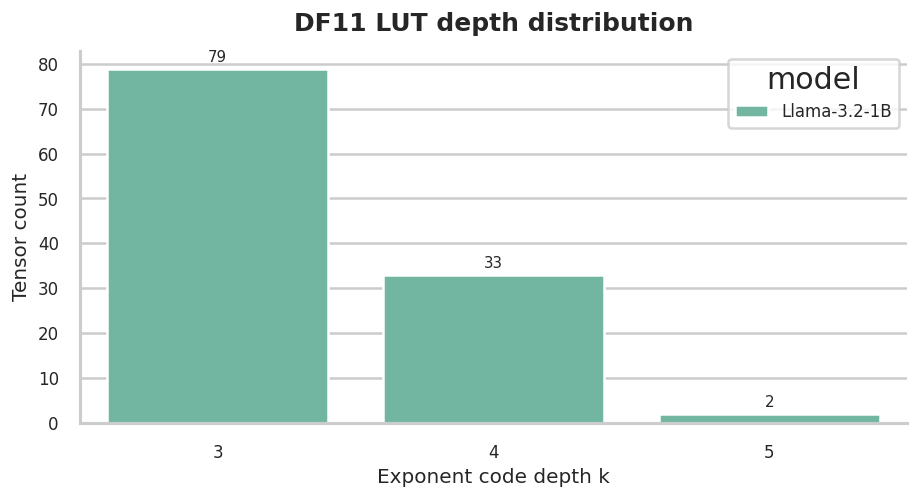

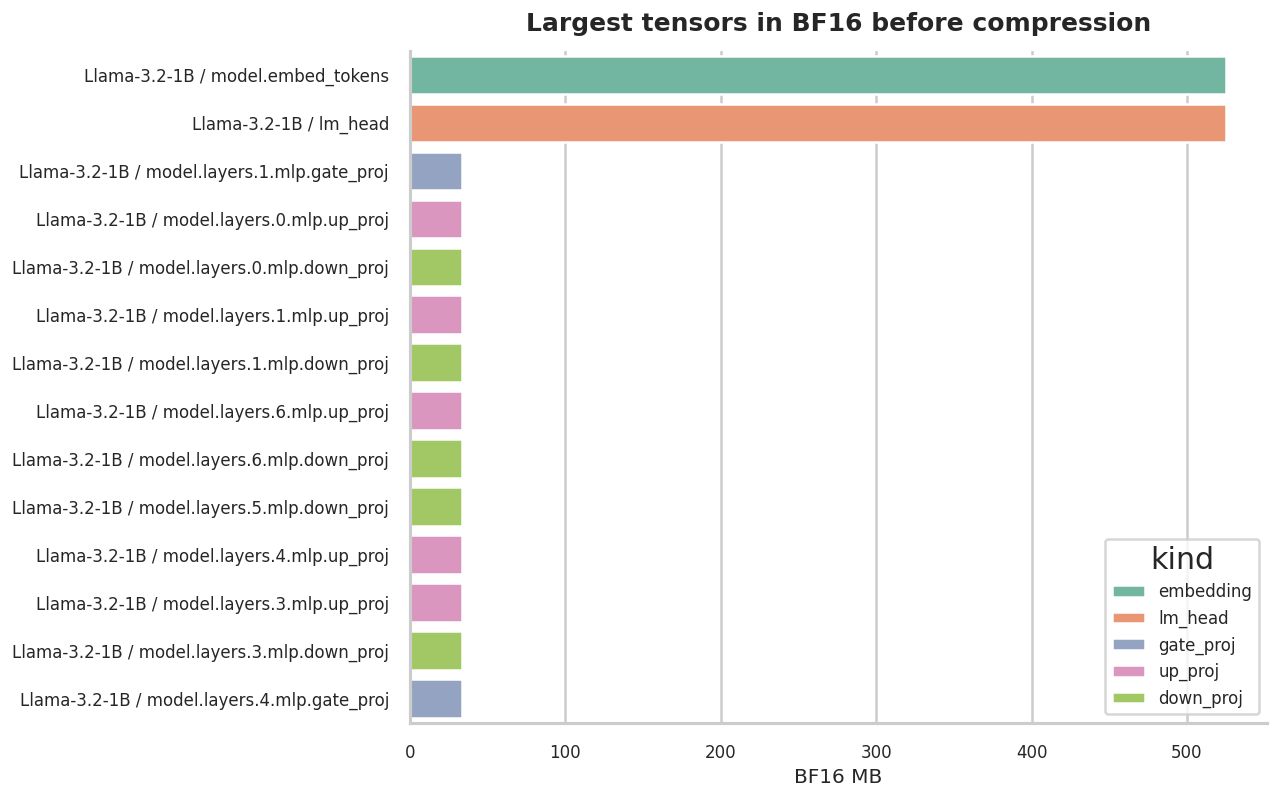

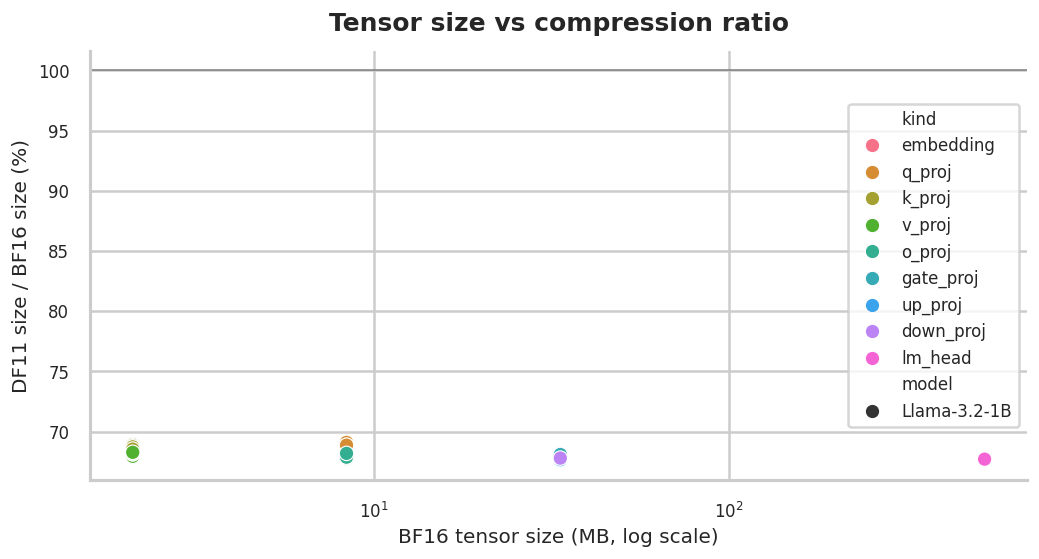

In [19]:
if tensor_df.empty:
    print("No tensor rows found yet.")
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.countplot(data=tensor_df, x="k", hue="model", ax=ax)
    annotate_bars(ax, "{:.0f}")
    finish(ax, "DF11 LUT depth distribution", xlabel="Exponent code depth k", ylabel="Tensor count")
    plt.show()

    largest = tensor_df.sort_values("original_mb", ascending=False).head(14).copy()
    largest["label"] = largest["model"] + " / " + largest["name"]
    fig, ax = plt.subplots(figsize=(11, 7))
    sns.barplot(data=largest, y="label", x="original_mb", hue="kind", dodge=False, ax=ax)
    finish(ax, "Largest tensors in BF16 before compression", xlabel="BF16 MB", ylabel="")
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.scatterplot(data=tensor_df, x="original_mb", y="compression_pct", hue="kind", style="model", s=75, ax=ax)
    ax.set_xscale("log")
    ax.axhline(100, color="black", linewidth=1, alpha=0.35)
    finish(ax, "Tensor size vs compression ratio", xlabel="BF16 tensor size (MB, log scale)", ylabel="DF11 size / BF16 size (%)")
    plt.show()